## Solução do Exemplo 2 - Reservatório de Cheias

Resolução via método das diferenças finitas.


Com condição inicial dada pela curva:

In [1]:
from math import sqrt
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Comprimento do talvegue
L = 3.1 # km

# Diferença de altitude
dh = 93/1000 # km

In [3]:
# declividade do talvegue principal (adimensional)
S = dh/L
print("A declividade do talvegue principal (adimensional) é", S)

# tempo de concentração
tc = 7.68 * (L/np.sqrt(S))**0.79
print("O tempo de concentração é", tc, "min")

A declividade do talvegue principal (adimensional) é 0.03
O tempo de concentração é 75.00221036826834 min


## Cálculo das constantes do HUS do SCS

* Tempo de pico (horas)
$$
t_p = 0.6 \, t_c
$$

* Tempo de ascensão (horas)
$$
T_p = t_p + \frac{d}{2}
$$

* Tempo de base (horas)
$$
t_b = T_p + 1.67 \, T_p
$$

* Vazão de pico (m3/s)
$$
q_p = \frac{0.208 \, A}{T_p}
$$

In [4]:
# tempo de pico (min)
tp = 0.6*tc
#print("O tempo de pico é", tp, "min")
print("tp:", tp, "min")

# duração da chuva (min)
d = 10
#print("A duração da chuva é", d, "min")
print(" d: ", d, "min")

# tempo de ascensão (min)
Tp = tp + d/2
#print("O tempo de ascensão é", Tp, "min")
print("Tp: ", Tp, "min")


tp: 45.001326220961 min
 d:  10 min
Tp:  50.001326220961 min


In [5]:
# criando um array para o tempo em intervalos de 1 minuto (de 0 a 300)
t = np.arange(0, 260, 1)
q = np.zeros(len(t))

In [6]:
q_qp = np.zeros(len(t))
m = 3.7

In [7]:
q_qp = np.exp(m)*((t/Tp)**m)*np.exp(-m*(t/Tp))
q = 4*q_qp

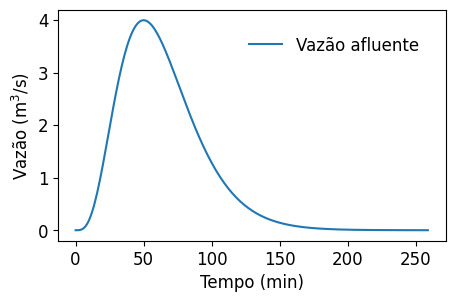

In [8]:
fig, ax = plt.subplots(figsize=(5,3))
ax.tick_params(axis='both', labelsize=12) #increase font size for ticks
plt.ylabel(r'Vazão (m$^3$/s)', fontsize=12) #y label
plt.xlabel(r'Tempo (min)', fontsize=12) #y label
ax.plot(t,q, label='Vazão afluente')
ax.legend()
ax.legend(loc="upper right",bbox_to_anchor=(0.97, 0.95), frameon=False, fontsize=12)
plt.savefig('afluente2.pdf', dpi = 300, bbox_inches='tight')
plt.show()